drop   → 40 points
full   → 40 points
mix    → 40 points


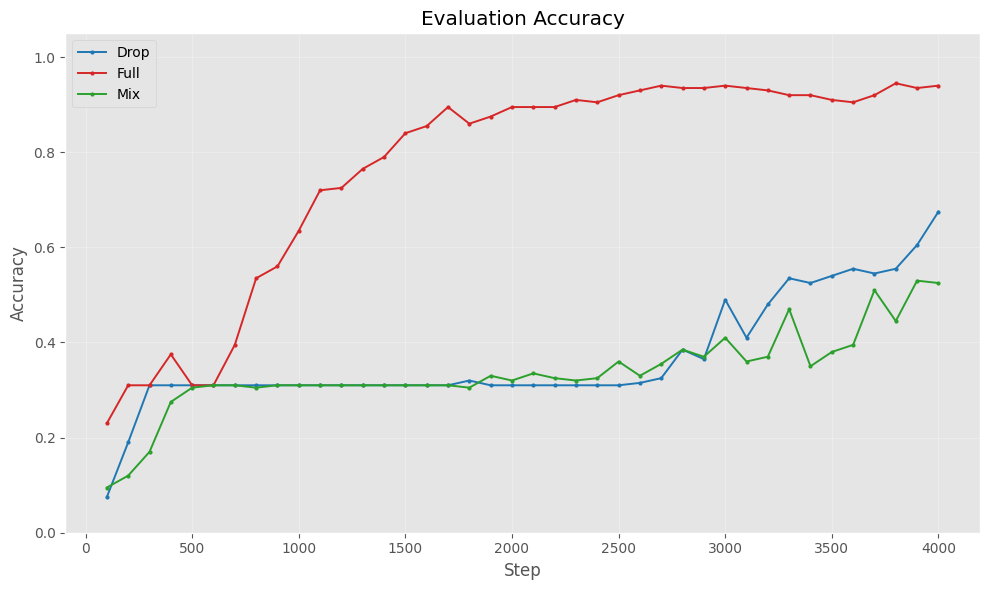

In [74]:
import re
import matplotlib.pyplot as plt
suffix="emotion"
files = {
    "drop": f"train_drop_{suffix}.txt",
    "full": f"train_full_{suffix}.txt",
    "mix":  f"train_mix_{suffix}.txt",
}

# Which metric to plot? (uncomment the one you want)
# METRIC = "train_loss"      # options: train_loss, eval_loss, accuracy, macro_f1
# METRIC = "eval_loss"
METRIC = "accuracy"
# METRIC = "macro_f1"

# ────────────────────────────────────────────────
# Parsing function
# ────────────────────────────────────────────────

def parse_log(filename):
    steps = []
    train_losses = []
    eval_losses = []
    accuracies = []
    macro_f1s = []

    step_pat      = re.compile(r"step=(\d+)")
    train_loss_pat = re.compile(r"'loss':\s*'([\d\.eE+-]+)'")
    eval_pat      = re.compile(r"'eval_loss':\s*'([\d\.eE+-]+)'.*?"
                              r"'eval_accuracy':\s*'([\d\.]+)'.*?"
                              r"'eval_macro_f1':\s*'([\d\.]+)'")

    current_step = None

    with open(filename, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            m = step_pat.search(line)
            if m:
                current_step = int(m.group(1))
                continue

            if current_step is None:
                continue

            if METRIC == "train_loss":
                m = train_loss_pat.search(line)
                if m:
                    steps.append(current_step)
                    train_losses.append(float(m.group(1)))

            else:
                m = eval_pat.search(line)
                if m:
                    steps.append(current_step)
                    if METRIC == "eval_loss":
                        eval_losses.append(float(m.group(1)))
                    elif METRIC == "accuracy":
                        accuracies.append(float(m.group(2)))
                    elif METRIC == "macro_f1":
                        macro_f1s.append(float(m.group(3)))

    if METRIC == "train_loss":
        return steps, train_losses
    elif METRIC == "eval_loss":
        return steps, eval_losses
    elif METRIC == "accuracy":
        return steps, accuracies
    elif METRIC == "macro_f1":
        return steps, macro_f1s

    return [], []

# ────────────────────────────────────────────────
# Collect data
# ────────────────────────────────────────────────

data = {}
for name, path in files.items():
    try:
        steps, values = parse_log(path)
        if values:
            data[name] = (steps, values)
            print(f"{name:6} → {len(values)} points")
        else:
            print(f"{name:6} → no {METRIC} values found")
    except Exception as e:
        print(f"Error reading {name}: {e}")

# ────────────────────────────────────────────────
# Plot
# ────────────────────────────────────────────────

if not data:
    print("No data to plot.")
else:
    plt.figure(figsize=(10, 6))
    plt.style.use('ggplot')

    colors = {"drop": "tab:blue", "full": "tab:red", "mix": "tab:green"}
    labels = {"drop": "Drop", "full": "Full", "mix": "Mix"}

    for name, (steps, values) in data.items():
        if values:
            plt.plot(steps, values, '.-', color=colors.get(name, "gray"),
                     label=labels.get(name, name), linewidth=1.4, markersize=4)

    title_map = {
        "train_loss": "Training Loss",
        "eval_loss":  "Evaluation Loss",
        "accuracy":   "Evaluation Accuracy",
        "macro_f1":   "Evaluation Macro F1"
    }

    plt.title(title_map.get(METRIC, METRIC.replace("_", " ").title()))
    plt.xlabel("Step")
    plt.ylabel(METRIC.replace("_", " ").title())

    if METRIC in ["accuracy", "macro_f1"]:
        plt.ylim(0, 1.05)

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()